In [10]:
import numpy as np
import nibabel as nib
import os 
from operator import itemgetter

dimensions = []

for mask in os.listdir("data/FCD2/Pathological/labels"):
    vol = nib.load(f"data/FCD2/Pathological/labels/{mask}")

    vol = np.array(vol.dataobj)

    indices = np.argwhere(vol == 1)

    if indices.size == 0:
        length = width = height = 0
    else:
        # Find min and max along each axis
        z_min, y_min, x_min = indices.min(axis=0)
        z_max, y_max, x_max = indices.max(axis=0)

        # Dimensions of the bounding box
        depth = z_max - z_min + 1
        height = y_max - y_min + 1
        width = x_max - x_min + 1

    # print(depth,height,width)
    dimensions.append([depth,height,width])

print(dimensions)

max_depth = max(dimensions, key = itemgetter(0))[0]
max_width = max(dimensions, key = itemgetter(1))[1]
max_height = max(dimensions, key = itemgetter(2))[2]

print(f"max_depth: {max_depth}, max_width: {max_width}, max_height: {max_height}")


[[26, 25, 25], [75, 49, 52], [34, 28, 40], [25, 13, 18], [29, 41, 28], [14, 13, 31], [12, 20, 24], [38, 14, 24], [35, 31, 25], [27, 16, 12], [31, 13, 16], [17, 14, 27], [30, 32, 34], [23, 21, 28], [30, 10, 28], [15, 13, 19], [18, 5, 18], [19, 27, 3], [25, 21, 46], [37, 35, 55], [19, 15, 33], [33, 11, 21], [35, 39, 11], [18, 35, 16], [14, 19, 13], [36, 20, 14], [12, 6, 25], [14, 26, 23], [16, 7, 15], [46, 18, 30], [40, 12, 32], [31, 29, 4], [21, 13, 13], [22, 18, 29], [21, 17, 32], [17, 20, 11], [19, 18, 22], [55, 30, 3], [21, 20, 19], [21, 24, 40], [29, 22, 34], [25, 31, 20], [17, 21, 12], [23, 9, 16], [25, 26, 42], [15, 19, 20], [18, 23, 26], [49, 54, 6], [19, 20, 26], [15, 24, 16], [31, 13, 13], [22, 7, 16], [10, 14, 27], [21, 20, 24], [24, 12, 27], [14, 16, 12], [18, 7, 9], [17, 24, 21], [20, 14, 17], [14, 18, 22], [40, 21, 48], [13, 14, 28], [22, 13, 31], [18, 34, 10], [46, 15, 24], [19, 33, 5], [16, 13, 29], [20, 12, 12], [25, 22, 19], [19, 13, 33], [21, 23, 32], [29, 23, 28], [20

So we observe that the maximum dimension of some lesion in $(160,256,256)$ volumes is 86 pixels. This means we can crop the images and corresponding masks to a $(96,96,96)$ region around each lesion and learn only to inpaint in the desired region. This clever trick should allow us to train in the original pixel space while significantly reducing memory requirements. In the following section, we create `data/FCD2_PATCH`.

# FCD2-PATCH

Here's the procedure implemented for a single arbitrary sample:

center: [ 69  91 192]
original mask:


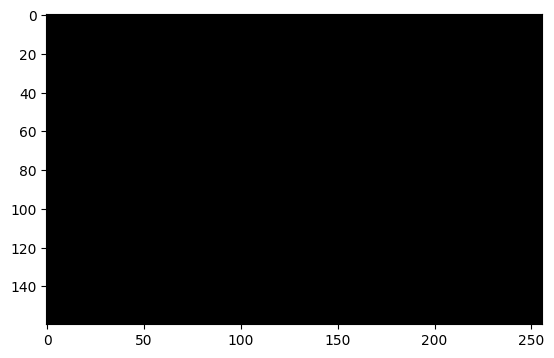

mask patch:


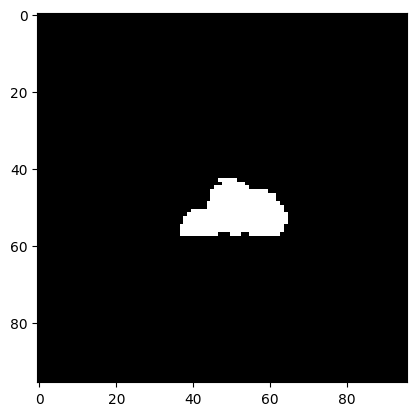

original image:


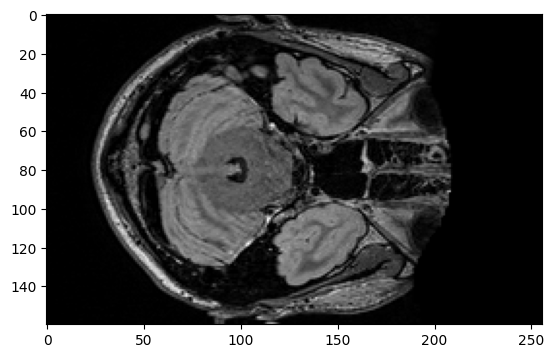

image patch:


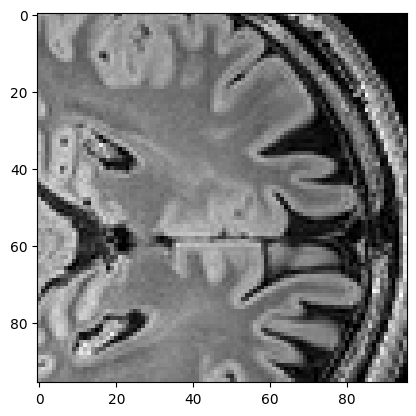

In [18]:
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt

fcd2_dir = "data/FCD2/Pathological"
images_dir = fcd2_dir + "/images"
labels_dir = fcd2_dir + "/labels"

image_files = sorted(os.listdir(images_dir))
label_files = sorted(os.listdir(labels_dir))

index = 20

# try with one first
mask = nib.load(os.path.join(labels_dir, label_files[index]))
mask_array = np.array(mask.dataobj)
indices = np.argwhere(mask_array == 1)

max = indices.max(axis=0)
min = indices.min(axis=0)
center = (max + min) // 2

print(f"center: {center}")

half_size = 48

start = center - half_size
end = center + half_size
####################################################
mask_patch = mask_array[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
####################################################
image = nib.load(os.path.join(images_dir, image_files[index]))
image_array = np.array(image.dataobj)

image_patch = image_array[start[0]:end[0], start[1]:end[1], start[2]:end[2]]

print("original mask:")
slice = mask_array[:,:,128]
plt.imshow(slice, cmap='gray')
plt.show()

print("mask patch:")
slice1 = mask_patch[:,48,:]
plt.imshow(slice1, cmap='gray')
plt.show()

print("original image:")
slice = image_array[:,:,128]
plt.imshow(slice, cmap='gray')
plt.show()

print("image patch:")
slice1 = image_patch[:,48,:]
plt.imshow(slice1, cmap='gray')
plt.show()

And now, of course, we do this for every sample:

In [ ]:
import nibabel as nib
import numpy as np
import os
from scipy.ndimage import zoom

# Paths
base_dir = "data"
input_dir = os.path.join(base_dir, "FCD2/Pathological")
output_dir = os.path.join(base_dir, "FCD2_PATCH/Pathological")

images_dir = os.path.join(input_dir, "images")
labels_dir = os.path.join(input_dir, "labels")

patch_images_dir = os.path.join(output_dir, "images")
patch_labels_dir = os.path.join(output_dir, "labels")

os.makedirs(patch_images_dir, exist_ok=True)
os.makedirs(patch_labels_dir, exist_ok=True)

# Parameters
patch_size = 48
half_size = patch_size // 2

# Sorted files to maintain correct pairing
image_files = sorted(os.listdir(images_dir))
label_files = sorted(os.listdir(labels_dir))

for i, (img_file, lbl_file) in enumerate(zip(image_files, label_files)):
    image = nib.load(os.path.join(images_dir, img_file))
    mask = nib.load(os.path.join(labels_dir, lbl_file))

    image_array = np.array(image.dataobj)
    mask_array = np.array(mask.dataobj)

    # Resize the image and mask to half the size
    image_array = zoom(image_array, (0.5, 0.5, 0.5), order=1)
    mask_array = zoom(mask_array, (0.5, 0.5, 0.5), order=0)

    indices = np.argwhere(mask_array == 1)
    if indices.size == 0:
        print(f"Skipping {img_file} - no lesion found.")
        continue

    center = ((indices.max(0) + indices.min(0)) // 2).astype(int)

    # Compute start and end, then pad if needed
    def crop_or_pad(arr):
        start = center - half_size
        end = center + half_size
        pad_before = np.maximum(-start, 0)
        pad_after = np.maximum(end - np.array(arr.shape), 0)
        start = np.maximum(start, 0)
        end = np.minimum(end, arr.shape)
        cropped = arr[start[0]:end[0], start[1]:end[1], start[2]:end[2]]
        padded = np.pad(cropped,
                        ((pad_before[0], pad_after[0]),
                         (pad_before[1], pad_after[1]),
                         (pad_before[2], pad_after[2])),
                        mode='constant', constant_values=0)
        return padded

    image_patch = crop_or_pad(image_array)
    mask_patch = crop_or_pad(mask_array)

    # Save patches
    patch_img_nib = nib.Nifti1Image(image_patch, affine=image.affine)
    patch_lbl_nib = nib.Nifti1Image(mask_patch, affine=mask.affine)

    nib.save(patch_img_nib, os.path.join(patch_images_dir, img_file))
    nib.save(patch_lbl_nib, os.path.join(patch_labels_dir, lbl_file))

    print(f"Saved patch {i}: {img_file}")


Saved patch 0: sub-00001_acq-T2sel_FLAIR.nii.gz
Saved patch 1: sub-00003_acq-T2sel_FLAIR.nii.gz
Saved patch 2: sub-00004_acq-T2sel_FLAIR.nii.gz
Saved patch 3: sub-00006_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 4: sub-00009_acq-T2sel_FLAIR.nii.gz
Saved patch 5: sub-00010_acq-T2sel_FLAIR.nii.gz
Saved patch 6: sub-00014_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 7: sub-00015_acq-T2sel_FLAIR.nii.gz
Saved patch 8: sub-00016_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 9: sub-00018_acq-corhipp4mm_FLAIR.nii.gz
Saved patch 10: sub-00020_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 11: sub-00024_acq-T2sel_FLAIR.nii.gz
Saved patch 12: sub-00027_acq-traAcpc4mm_FLAIR.nii.gz
Saved patch 13: sub-00032_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 14: sub-00033_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 15: sub-00034_acq-T2sel_FLAIR.nii.gz
Saved patch 16: sub-00038_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 17: sub-00040_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 18: sub-00043_acq-tse3dvfl_FLAIR.nii.gz
Saved patch 19: sub-00044_acq-T2sel_FLAIR.